качаем библиотеки

In [1]:
import pandas as pd
import numpy as np

import statistics
import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm
from scipy.stats import t

#### Проект
Наша кампания ранне имела всего один продукт, он был запущен давно. У нас есть записи сколько выручки нам приносил этот продукт за каждый день его работы. Пару месяцев назад кампания запустила второй продукт, и так же ежедневно фиксировала выручку которую он нам приносил. Данные по выручкам сохранены ниже в переменных product1 и product2.<br>
Наша задача сделать полный анализ на основе всего лишь этих двух списках.

In [3]:
### для загрузки данных
with open(r'project.txt', 'r') as fp:
    for i, line in enumerate(fp):
        if i == 0:
            product1 = [int(i) for i in line.split(' ')]
        if i == 1:
            product2 = [int(i) for i in line.split(' ')]

fp.close()

**Задача 1**<br>
подсчитайте среднее арифметическое (mean), медиану и моду для обоих списков: product1 и product2

In [7]:
product1_mean = np.mean(product1)
product1_median = np.median(product1)
product1_mode = statistics.mode(product1)
print(f'Среднее арифметическое product1: {product1_mean}')
print(f'Медиана product1: {product1_median}')
print(f'Мода product1: {product1_mode}')
print('\n')
product2_mean = np.mean(product2)
product2_median = np.median(product2)
product2_mode = statistics.mode(product2)
print(f'Среднее арифметическое product2: {product2_mean}')
print(f'Медиана product2: {product2_median}')
print(f'Мода product2: {product2_mode}')

Среднее арифметическое product1: 199.103
Медиана product1: 198.5
Мода product1: 186


Среднее арифметическое product2: 193.5
Медиана product2: 194.5
Мода product2: 227


Какая из трех метрик будет наименее показательной, и почему?<br>
На основе оставшихся двух метрик какой продукт в среднем приносит больше выручки?

Наименее показательная метрика — мода, так как она отражает только самое частое значение и не учитывает распределение данных.
По среднему и медиане product1 приносит больше выручки чем product2.

**Задача 2**<br>
подсчитайте стандартное отклонение и скажите оценка какого продукта является более точной?

In [9]:
std_1 = np.std(product1)
std_2 = np.std(product2)
print(std_1, std_2)

28.793964489107783 29.589018233121557


Оценка продукта 1 более точная, так как стандартное отклонение у него меньше, что говорит о меньшем разбросе данных и большей стабильности значений.

**Задача 3**<br>
Нарисуйте распределение вероятности выручки для продукта1 и для продукта2.<br>
Можете использовать гистограмму или kdeplot

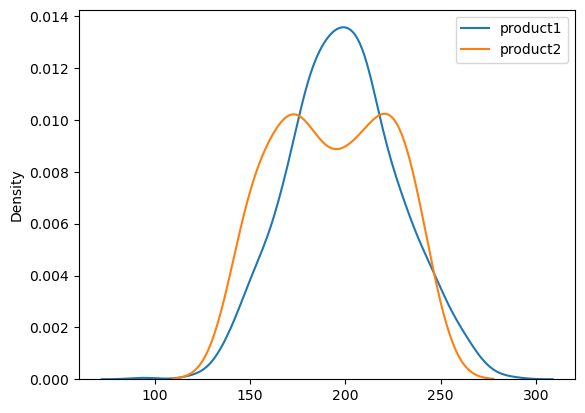

In [12]:
sns.kdeplot(product1, label = 'product1')
sns.kdeplot(product2, label = 'product2')
plt.legend()
plt.show()

**Задача 4**<br>
Посчитайте размах выручки для продукта1 и для продукта2<br>
Сходится ли разница в размахах и разница в стандартных отклонениях, какая может быть причина?

In [14]:
range_1 = np.max(product1) - np.min(product1)
range_2 = np.max(product2) - np.min(product2)

print(f'Размах выручки product1: {range_1}')
print(f'Размах выручки product2: {range_2}')

Размах выручки product1: 193
Размах выручки product2: 97


Стандартное отколение и размах не сходятся у product1. Это означает что у 1 продукта есть выбросы. Но размах учитывает только крайние значения, а стд учитывает все наблюдения

**Задача 5**<br>
Посчитайте межквартильный разммах IQR для продукта1 и продукта2<br>
Теперь убрав выбросы что мы можем сказать о разбросе данных?

In [16]:
IQR_1 = np.percentile(product1, 75) - np.percentile(product1, 25)
IQR_2 = np.percentile(product2, 75) - np.percentile(product2, 25)

print(f'IQR product1: {IQR_1}')
print(f'IQR product2: {IQR_2}')

IQR product1: 38.25
IQR product2: 51.0


Не учитывая выбросы, разброс данных у продукта 1 меньше, то есть основная масса данных распределены более стабильно
В то время как у продукта 2 несмотря на маленький размах, основная масса данных распределены шире

**Задача 6**<br>
Нарисуйте box-plot для продукта1 и с рисунка скажите при каких значениях начинаются выбросы

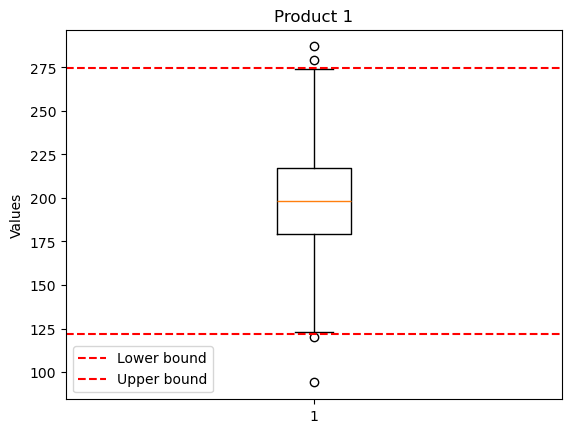

In [20]:
plt.boxplot(product1)
Q1 = np.percentile(product1, 25)
Q3 = np.percentile(product1, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
plt.axhline(lower_bound, color='red', linestyle='--', label='Lower bound')
plt.axhline(upper_bound, color='red', linestyle='--', label='Upper bound')
plt.title("Product 1")
plt.ylabel("Values")
plt.legend()
plt.show()

Выбросы для product1 начинаются за пределами интервала lower_bound - upper_bound. 
Значения, выходящие за эти границы, считаются выбросами и отображаются на boxplot в виде отдельных точек.

**Задача 7**<br>
Нарисуйте QQ plot выручки для обоих продуктов<br>
Какое из распределений является нормальным?

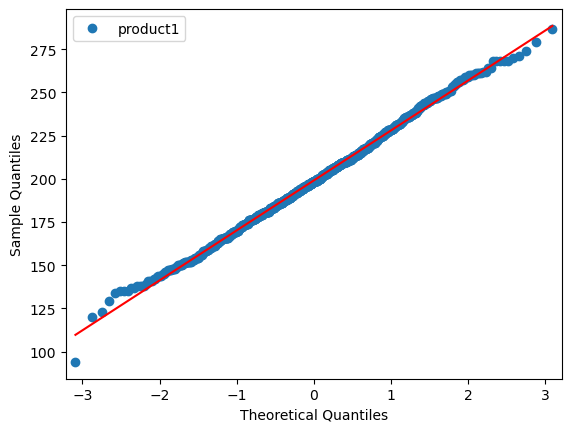

In [24]:
product1_qq = sm.qqplot(np.array(product1), line='r', label = 'product1')
plt.legend()
plt.show()

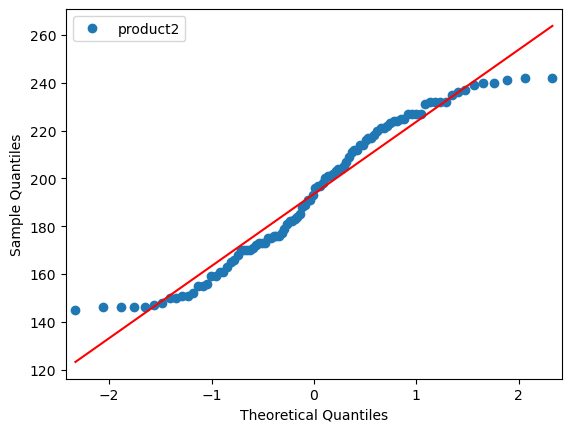

In [25]:
product2_qq = sm.qqplot(np.array(product2), line='r', label = 'product2')
plt.legend()
plt.show()

Распределение 1 продукта является нормальным в то время как распределение 2 продукта сильнее отклоняется от линии

Каких значений много или наоборот не достает в продукте2 чтобы значения стали нормально распределенными?

Значения больше сосредоточены в центре, по краям видно что много экстремально маленьких значении, мало экстремально больших значении

**Задача 8**<br>
И так мы знаем что выручка продукта1 является нормально распредленной, переведите все значения в стандартное нормальное распределение используя текущие mean и std<br>
создайте новую переменнуя и запишите новые значения туда

In [27]:
product1_mean = np.mean(product1)
product1_std = np.std(product1)

product1_standard = (product1 - product1_mean) / product1_std

Нарисуйте kdeplot нового стандартного распределения

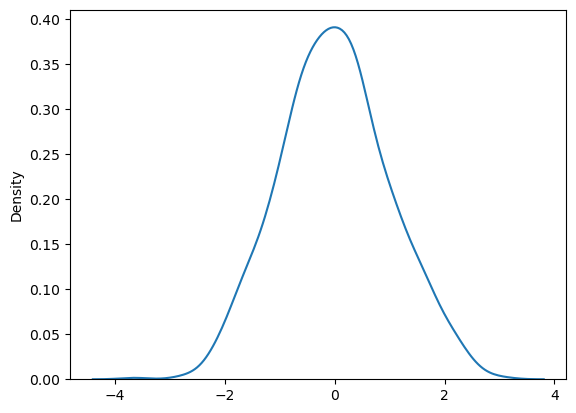

In [28]:
sns.kdeplot(product1_standard)
plt.show()

**Задача 9**<br>
Подсчитайте точку слева от которой будет 1% всей вероятности распределения

In [31]:
point = norm.ppf(0.01)
print(point)

-2.3263478740408408


Первое значение в списке product1 равно 94. Когда мы преобразуем список в стандартное нормальное распределение, 94 преобразуется в -3.65<br>
Что нам говорит это число, особенно при сравнении с точкой которую мы только что подсчитали?

Это число говорит нам о том, что оно находится на 3.65 стандартных отклонения ниже среднего, при сравнении с точкой квантиля 1%, оно относится к ркайне редким наблюдениям и вероятность попадания этого числа меньше одного процента.

**Задача 10**<br>
Продукт2 новый, но уже достаточно стабилизирвался за эти месяцы. Мы хотим знать сколько он будет в среднем нам приносить ежедневно выручки и в будущем.<br>
Дайте точечную оценку средней выручке продукта2

In [33]:
print(f'Точечная оценка средней выручки продукта 2: {product2_mean}')

Точечная оценка средней выручки продукта 2: 193.5


Подсчитайте 95% доверительный интервал

In [34]:
product2_std = np.std(product2)

ul = norm.ppf(0.975, loc = product2_mean, scale = product2_std)
ll = norm.ppf(0.025, loc = product2_mean, scale = product2_std)
print(ll, ul)

135.50658992518277 251.49341007481723


**Задача11**<br>
Проведите АБ тест с уровнем значимости 5% что средняя выручка у продукта1 выше чем 197.5

In [46]:
control_mean = 197.5

mean = np.mean(product1)
std = np.std(product1)
n = len(product1)
dof = n - 1
err_diff = std / np.sqrt(n)
t_stat = (mean - control_mean) / err_diff
p_value = 1 - t.cdf(t_stat, dof)

print(f't_stat: {t_stat}')
print(f'p_value: {p_value}')
print('\n')
alpha = 0.05
if p_value < alpha:
    print("Отвергаем H0: средняя выручка выше чем 197.5")
else:
    print("Не отвергаем H0: недостаточно доказательств")

t_stat: 1.760483899730965
p_value: 0.039315878320872244


Отвергаем H0: средняя выручка выше чем 197.5


Какой это был типа АБ теста?

one sample t test

**Задача12**<br>
Проведите АБ тест с уровнем значимости 5% что средняя выручка у продукта1 и у продукта2 равны

In [44]:
mean1 = np.mean(product1)
mean2 = np.mean(product2)
std1 = np.std(product1, ddof = 1)
std2 = np.std(product2, ddof = 1)
n1 = len(product1)
n2 = len(product2)

se = np.sqrt(std1 ** 2 / n1 + std2 ** 2 / n2)
z_stat = (mean1 - mean2) / se
p_value = 2 * (1 - norm.cdf(abs(z_stat)))

print(f'z_stat: {z_stat}')
print(f'p_value: {p_value}')
print('\n')
alpha = 0.05
if p_value < alpha:
    print("Отвергаем H0:  средняя выручка у продукта1 и у продукта2 не равны")
else:
    print("Не отвергаем H0: недостаточно доказательств что средняя выручка у продукта1 и у продукта2 не равны")

z_stat: 1.8014812850572308
p_value: 0.0716270544739086


Не отвергаем H0: недостаточно доказательств что средняя выручка у продукта1 и у продукта2 не равны
